In [1]:
using DelimitedFiles, FileIO
using JLD2
using CairoMakie
using NCDatasets
using ClimaOcean.Bathymetry: remove_minor_basins!

┌ Warning: You are using Julia v1.11 or later!"
│ Oceananigans is currently tested on Julia v1.10."
│ If you find issues with Julia v1.11 or later,"
│ please report at https://github.com/CliMA/Oceananigans.jl/issues/new
└ @ Oceananigans ~/.julia/packages/Oceananigans/NPiIU/src/Oceananigans.jl:118


In [67]:
using Interpolations

In [2]:
#datapath = joinpath(homedir(), "FjordsSim_data", "sognefjord")
netcdf_path = joinpath("Isafjardardjup_topo.nc")

"Isafjardardjup_topo.nc"

In [3]:
dataset = NCDataset(netcdf_path);

In [4]:
dataset

Dataset: Isafjardardjup_topo.nc
Group: /

Dimensions
   y = 651
   x = 641

Variables
  depth   (641 × 651)
    Datatype:    Union{Missing, Float64} (Float64)
    Dimensions:  x × y
    Attributes:
     _FillValue           = NaN
     coordinates          = dlat dlon latv lonv

  depth_fjord   (641 × 651)
    Datatype:    Union{Missing, Float64} (Float64)
    Dimensions:  x × y
    Attributes:
     _FillValue           = NaN
     coordinates          = dlat dlon latv lonv

  area_km2   (641 × 651)
    Datatype:    Union{Missing, Float64} (Float64)
    Dimensions:  x × y
    Attributes:
     _FillValue           = NaN
     coordinates          = dlat dlon latv lonv

  lon_grid   (641 × 651)
    Datatype:    Union{Missing, Float64} (Float64)
    Dimensions:  x × y
    Attributes:
     _FillValue           = NaN
     coordinates          = dlat dlon latv lonv

  lat_grid   (641 × 651)
    Datatype:    Union{Missing, Float64} (Float64)
    Dimensions:  x × y
    Attributes:
     _FillValue

In [156]:
m = -dataset["depth"][45:end,1:640];

In [170]:
lon = dataset["lon_grid"][45:end, 1:640];

In [171]:
lat = dataset["lat_grid"][45:end, 1:640];

In [179]:
lat[:,end]

597-element Vector{Union{Missing, Float64}}:
 66.399
 66.399
 66.399
 66.399
 66.399
 66.399
 66.399
 66.399
 66.399
 66.399
 66.399
 66.399
 66.399
  ⋮
 66.399
 66.399
 66.399
 66.399
 66.399
 66.399
 66.399
 66.399
 66.399
 66.399
 66.399
 66.399

In [157]:
m = coalesce.(m, 0.0)

597×640 Matrix{Float64}:
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  -152.191  -152.425  -152.727  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -150.194  -151.207  -150.639  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -149.853  -149.206  -147.962  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -151.962  -150.92   -150.25   0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -152.18   -150.983  -150.258  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  -147.815  -147.212  -146.58   0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -147.048  -146.218  -145.029  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -147.513  -147.324  -147.652  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -144.652  -145.923  -147.06   0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -137.53   -140.384  -143.26   0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  -136.394  -140.081  -140.626  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -139.551  -138.771  -135.033  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0

In [155]:
# m[m .>= -5] .= 0;

In [136]:
remove_minor_basins!(m, 1)

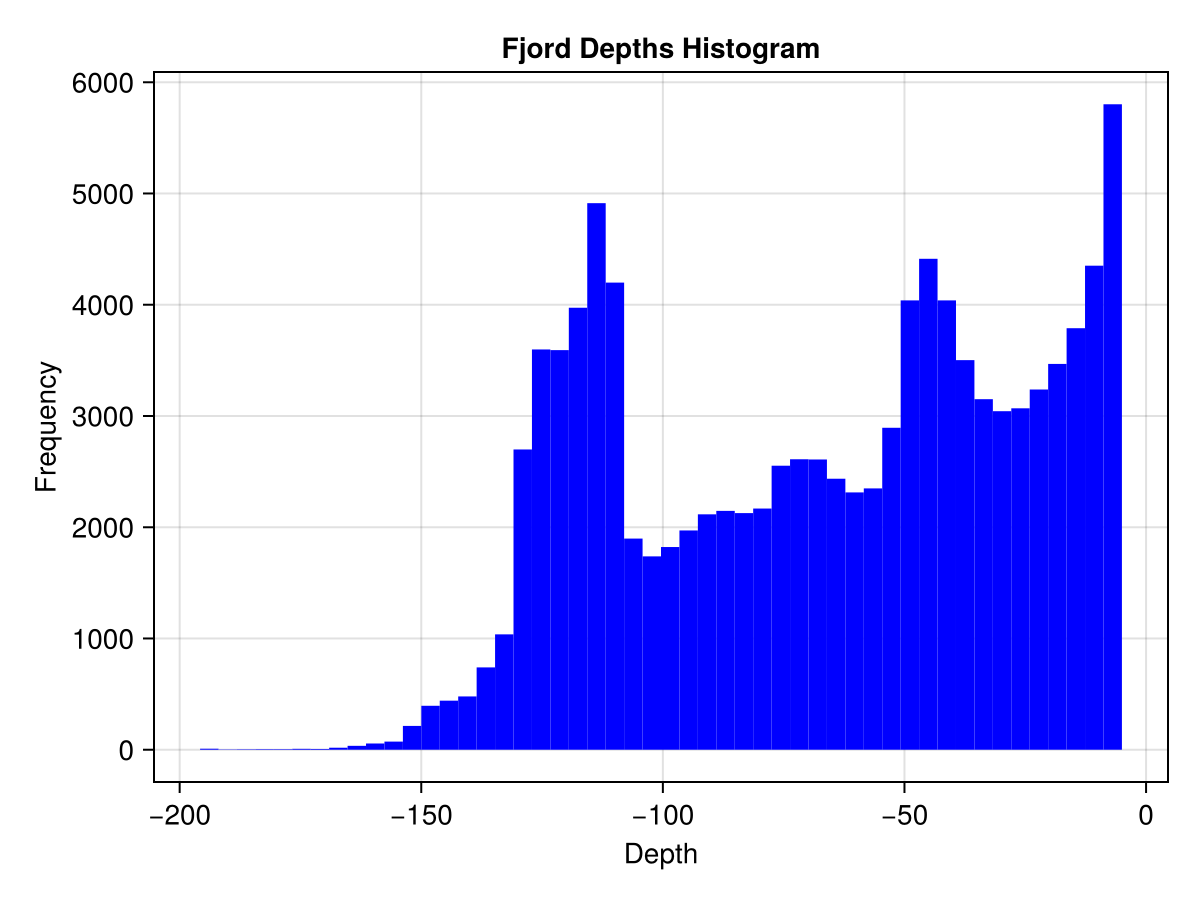

In [137]:
depth_values = vec(m)  # Flatten the matrix
depth_values = filter(x -> x != 0.0, depth_values)  # Remove zeros as they represent missing data

f = Figure()
Axis(f[1, 1], title="Fjord Depths Histogram", xlabel="Depth", ylabel="Frequency")
hist!(f[1, 1], depth_values, bins=50, color=:blue)
f

In [138]:
z_faces = [
      -190.0,
    -170.0,
      -150.0,
    -140.0,
    -130.0,
    -120.0,
    -110.0,
      -100.0,
    -90.0,
    -80.0,
    -70.0,
      -60.0,
      -50.0,
    -40.0,
      -30.0,
    -25.0,
      -20.0,
    -18.0,
    -16.0,
    -14.0,
    -12.0,
      -10.0,
    -8.0,
    -6.0,
    -5.0,
    -4.0,
    -3.0,
       -2.0,
    -1.0,
        0.0
];

In [165]:
length(z_faces)

30

In [139]:
xs = [1, 345, 425, 480, 510]
ys = [560, 340, 320, 260, 240]

xs_interp = 2:510
interp_line = LinearInterpolation(xs, ys)
ys_interp = interp_line(xs_interp);

In [140]:
# Interpolate matrix
itp = interpolate(m, BSpline(Linear()))
itp = extrapolate(itp, 0.0);  # handle out-of-bounds safely

In [141]:
depth_transect = [itp[x, y] for (x, y) in zip(xs_interp, ys_interp)];

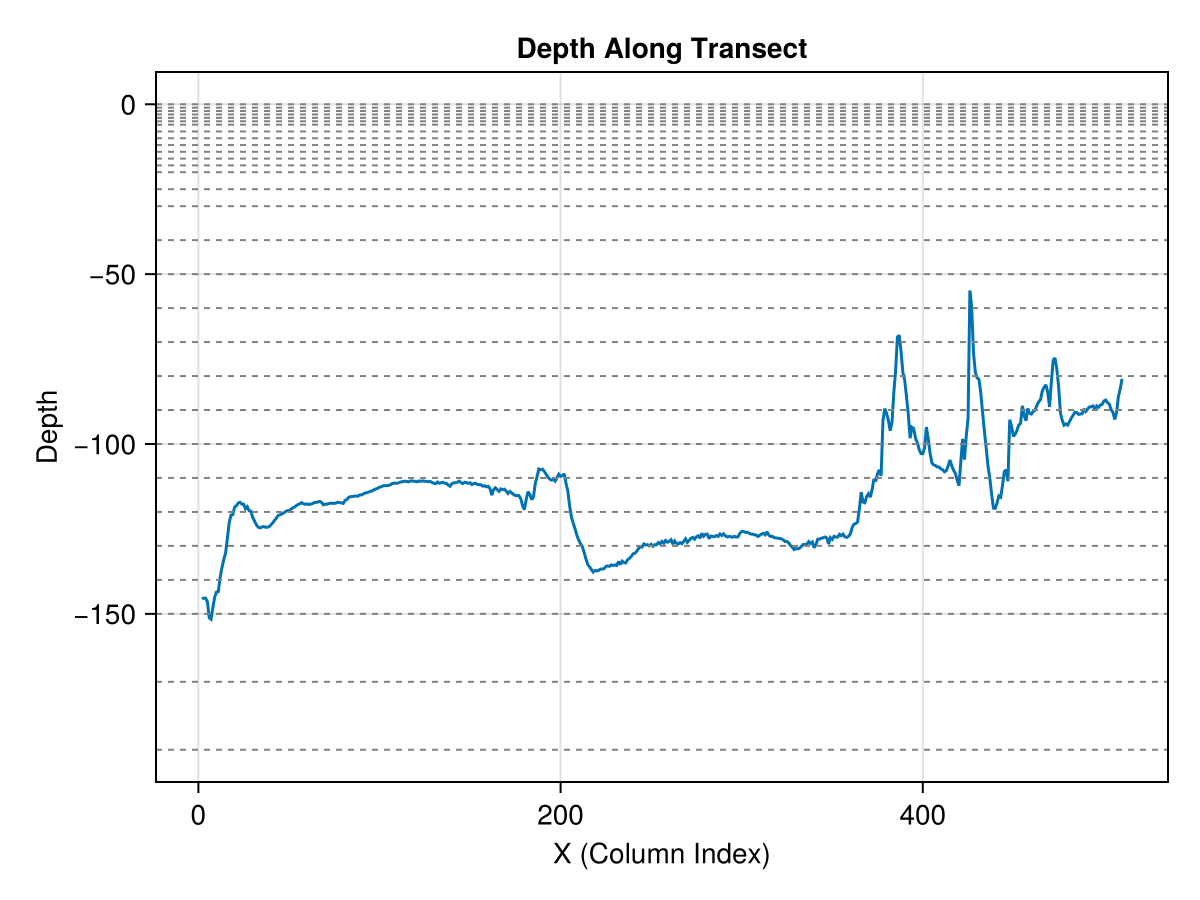

In [142]:
f = Figure()
ax = Axis(f[1, 1], title="Depth Along Transect", xlabel="X (Column Index)", ylabel="Depth")
lines!(f[1, 1], xs_interp, depth_transect)

for z in z_faces
    hlines!(ax, z, color=:gray, linestyle=:dash, linewidth=1)
end

f

In [158]:
m[-10 .<= m .< 0] .= -10;

In [159]:
maximum(filter(!isnan, ifelse.(m .== 0, NaN, m)))

-10.0

In [160]:
m2 = m[1:2:end, 1:2:end]

299×320 Matrix{Float64}:
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  -152.693  -152.191  -152.727
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -152.584  -149.853  -147.962
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -154.545  -152.18   -150.258
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -149.902  -147.048  -145.029
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -146.955  -144.652  -147.06
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  -139.966  -136.394  -140.626
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -137.126  -137.108  -133.631
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -137.108  -128.904  -128.648
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -136.247  -126.186  -120.19
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -135.064  -126.372  -118.953
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  -127.739  -123.478  -118.779
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -116.575  -117.535  -114.703
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  

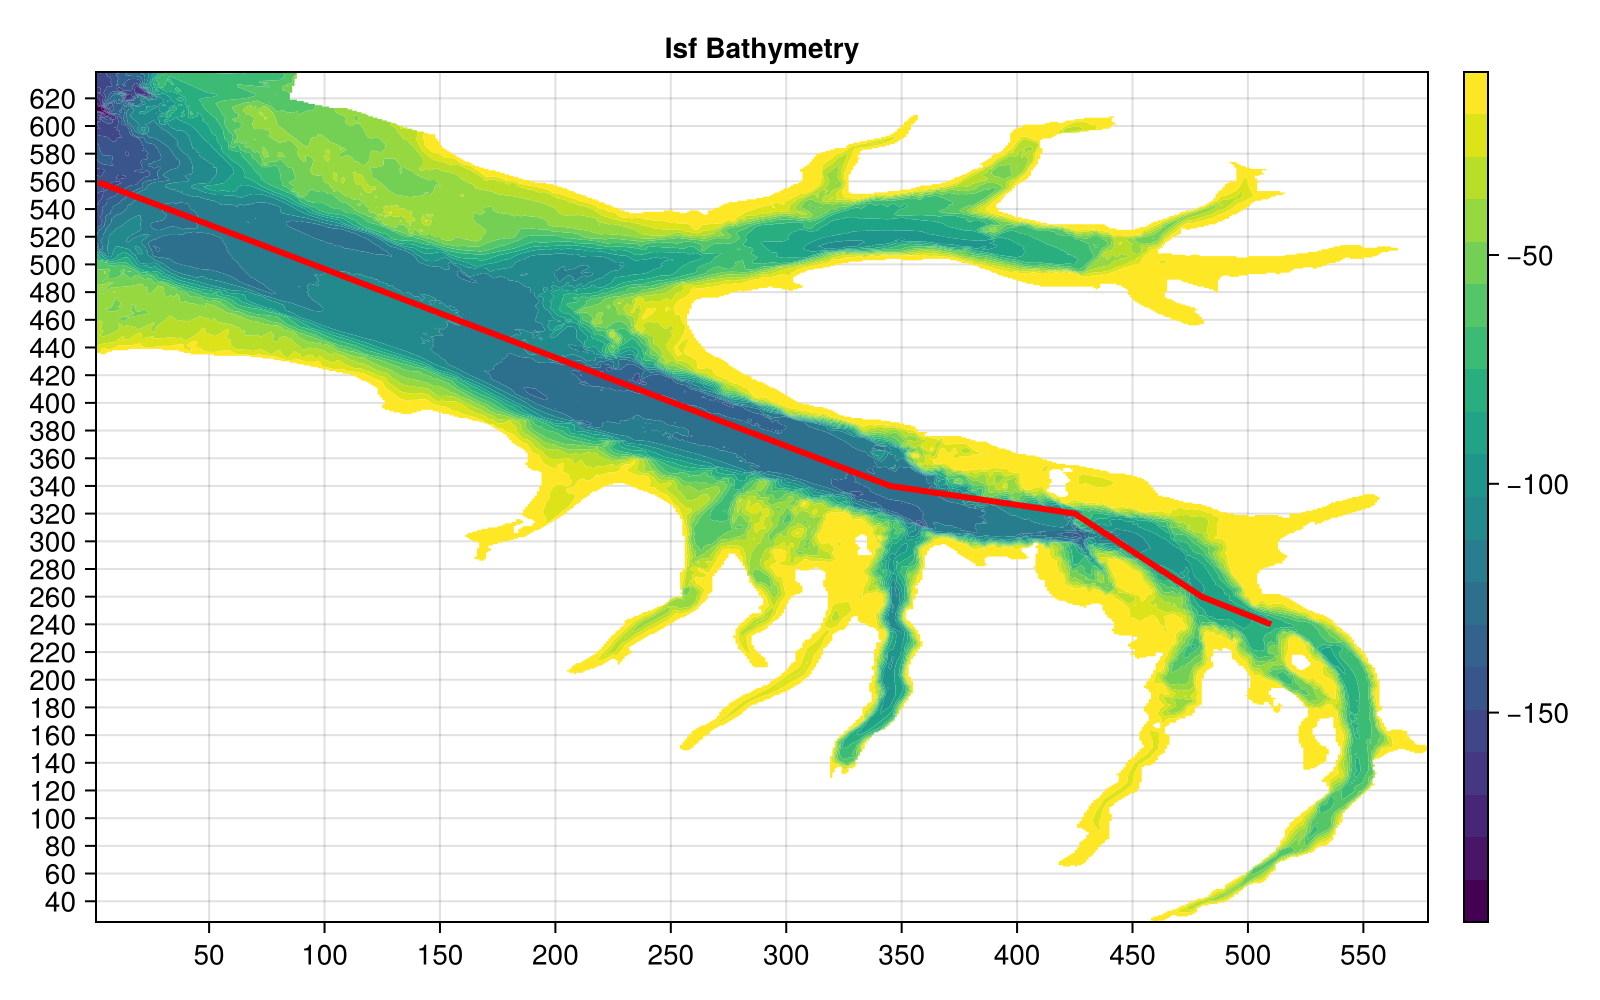

In [161]:
fig = Figure(size = (800, 500))
ax = Axis(fig[1, 1], title = "Bathymetry", yticks=0:20:640, xticks=0:50:600)
ax.title = "Isf Bathymetry"
cf = contourf!(ax, ifelse.(m .== 0, NaN, m), levels=20)
Colorbar(fig[1, 2], cf)
lines!(ax, xs_interp, ys_interp, color=:red, linewidth=3)
fig

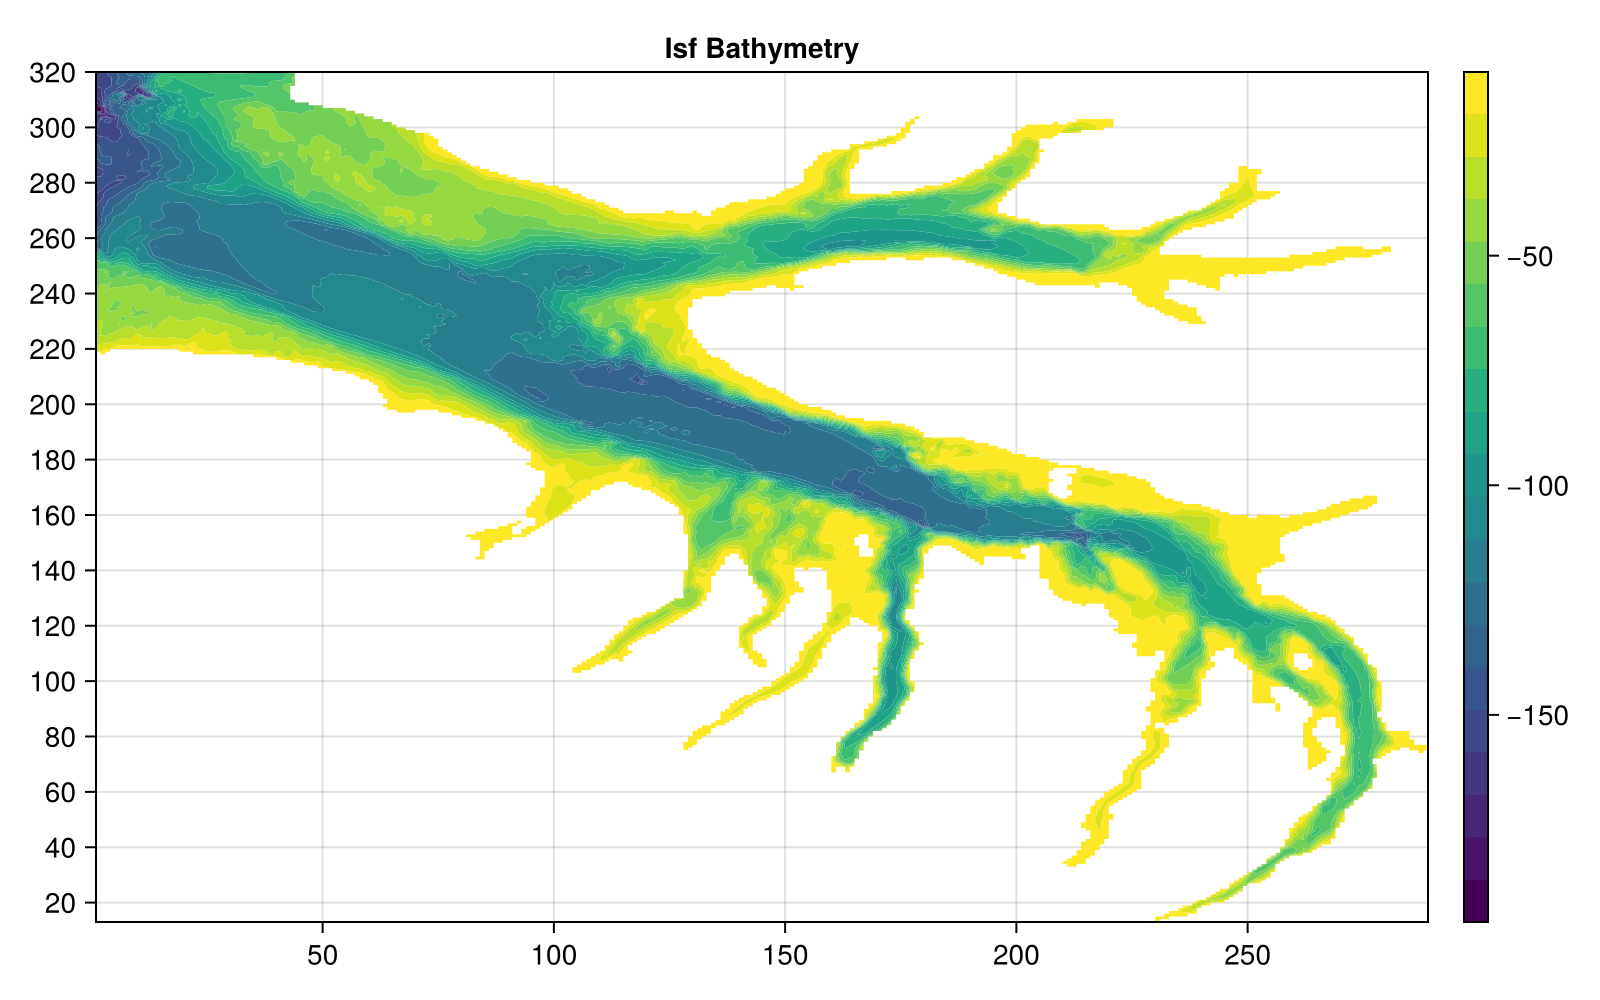

In [162]:
fig = Figure(size = (800, 500))
ax = Axis(fig[1, 1], title = "Bathymetry", yticks=0:20:640, xticks=0:50:600)
ax.title = "Isf Bathymetry"
# cf = contourf!(ax, ifelse.(m .== 0, NaN, m))
cf = contourf!(ax, ifelse.(m2 .== 0, NaN, m2), levels=20)
Colorbar(fig[1, 2], cf)
fig

In [163]:
m2

299×320 Matrix{Float64}:
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  -152.693  -152.191  -152.727
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -152.584  -149.853  -147.962
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -154.545  -152.18   -150.258
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -149.902  -147.048  -145.029
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -146.955  -144.652  -147.06
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  -139.966  -136.394  -140.626
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -137.126  -137.108  -133.631
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -137.108  -128.904  -128.648
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -136.247  -126.186  -120.19
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -135.064  -126.372  -118.953
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  -127.739  -123.478  -118.779
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -116.575  -117.535  -114.703
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  

In [164]:
@save joinpath("Isf_topo299x320.jld2") "depth" = m2 "z_faces" = z_faces